**IMDB Binary Text Classification:**

**Project Description:**

This project


In [1]:
!tar -xzf aclImdb_v1.tar.gz

In [2]:
!ls

aclImdb  aclImdb_v1.tar.gz  sample_data


In [3]:
!ls aclImdb/train

labeledBow.feat  pos	unsupBow.feat  urls_pos.txt
neg		 unsup	urls_neg.txt   urls_unsup.txt


In [4]:
!ls aclImdb/test

labeledBow.feat  neg  pos  urls_neg.txt  urls_pos.txt


In [5]:
!cat aclImdb/train/pos/6248_7.txt

Being an Austrian myself this has been a straight knock in my face. Fortunately I don't live nowhere near the place where this movie takes place but unfortunately it portrays everything that the rest of Austria hates about Viennese people (or people close to that region). And it is very easy to read that this is exactly the directors intention: to let your head sink into your hands and say "Oh my god, how can THAT be possible!". No, not with me, the (in my opinion) totally exaggerated uncensored swinger club scene is not necessary, I watch porn, sure, but in this context I was rather disgusted than put in the right context.<br /><br />This movie tells a story about how misled people who suffer from lack of education or bad company try to survive and live in a world of redundancy and boring horizons. A girl who is treated like a whore by her super-jealous boyfriend (and still keeps coming back), a female teacher who discovers her masochism by putting the life of her super-cruel "lover" 

In [6]:
!rm -r aclImdb/train/unsup

In [7]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.4 MB/s eta 0:00:00


In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import keras
import tensorflow as tf
from keras import layers

from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Embedding,GRU,Dense,Bidirectional
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import keras_tuner as kt
from sklearn.metrics import roc_curve, auc

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
raw_train_ds = keras.utils.text_dataset_from_directory("aclImdb/train",batch_size=32,validation_split=0.2,subset='training',seed=42)

raw_val_ds = keras.utils.text_dataset_from_directory("aclImdb/train",batch_size=32,validation_split=0.2,subset='validation',seed=42)

raw_test_ds = keras.utils.text_dataset_from_directory("aclImdb/test",batch_size=32)

print("\n")
print(f"Number of batches in raw_train_ds:{raw_train_ds.cardinality()}")
print(f"Number of batches in raw_val_ds:{raw_val_ds.cardinality()}")
print(f"Number of batches in raw_test_ds:{raw_test_ds.cardinality()}")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


Number of batches in raw_train_ds:625
Number of batches in raw_val_ds:157
Number of batches in raw_test_ds:782


**Exploratory Data Analysis**

EDA is done only on the training data. Not on the validation and test set.

In [ ]:
#Light Cleaning for EDA

def clean_text_light(text):
  text = re.sub(r"<br\s*/?","",text) #remove HTML tags
  text = re.sub(r"[^a-zA-Z\s]","",text) # remove punctuation and numbers
  text = re.sub(r"\s+","",text) #multiple spaces

  return text.lower().strip()

In [ ]:
texts = []
labels = []

for text_batch,label_batch in raw_train_ds:
  for text,label in zip(text_batch.numpy(),label_batch.numpy()):
    texts.append(text.decode("utf-8"))
    labels.append(int(label))

In [ ]:
train_df = pd.DataFrame({"review":texts,"label":labels})
train_df['clean_review'] = train_df['review'].apply(clean_text_light)
train_df.head()

,review,label,clean_review
0,"""Pandemonium"" is a horror movie spoof that com...",0,pandemoniumisahorrormoviespoofthatcomesoffmore...
1,David Mamet is a very interesting and a very u...,0,davidmametisaveryinterestingandaveryunequaldir...
2,Great documentary about the lives of NY firefi...,1,greatdocumentaryaboutthelivesofnyfirefightersd...
3,It's boggles the mind how this movie was nomin...,0,itsbogglesthemindhowthismoviewasnominatedforse...
4,The concept of the legal gray area in Love Cri...,0,theconceptofthelegalgrayareainlovecrimescontri...


In [ ]:
train_df.shape

(20000, 3)

In [ ]:
train_df['label'].value_counts()

,count
label,
0,10038
1,9962


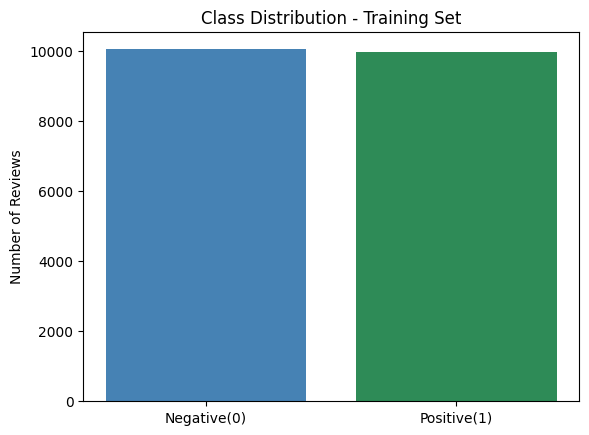



Class Percentage Distribution
0    50.19
1    49.81
dtype: float64


In [ ]:
#Class Distribution:

plt.bar(['Negative(0)','Positive(1)'],[10038,9962],color=['steelblue','seagreen'])
plt.title('Class Distribution - Training Set')
plt.ylabel('Number of Reviews')

plt.show()

#Percentage distribution
print("\n")
print("Class Percentage Distribution")
counts = pd.Series({0:10038,1:9962})
percentages = counts/counts.sum() * 100

print(percentages)

We can see from the above that the class is balanced.

Negative Sentiment/Reviews - 10038
Positive Sentiment/Reviews - 9962

This confirms there is no class imbalance.

In [ ]:
#Check for Missing or Empty Reviews

#Missing reviews

train_df['review'].isna().sum()

np.int64(0)

In [ ]:

#Check for empty reviews or whitespaces

empty_str = (train_df['review'].str.strip()=="").sum()
print(f"There are {empty_str} empty string")

There are 0 empty string


We can conclude from the above that there are no missing values and empty reviews.

**Text Length Analysis:**
**Word/Character Count Distribution:**

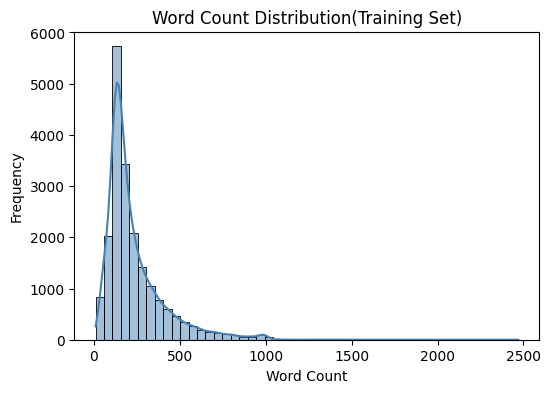

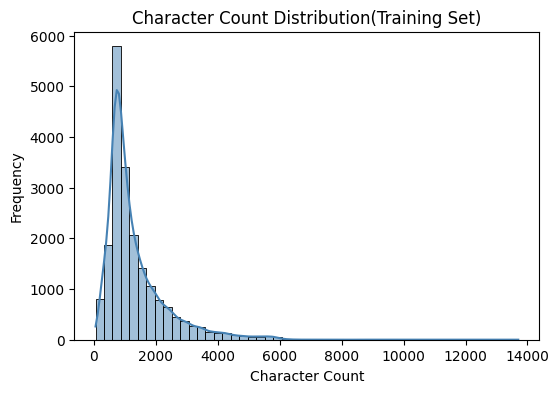

In [ ]:
#Calculate Word count and character count

train_df['word_count']=train_df['review'].apply(lambda x:len(x.split()))
train_df['char_count'] = train_df['review'].apply(lambda x:len(x))

#Word Count Distribution

plt.figure(figsize=(6,4))
sns.histplot(train_df['word_count'],bins=50,kde=True,color='steelblue')
plt.title('Word Count Distribution(Training Set)')
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#Character Count Distribution

plt.figure(figsize=(6,4))
sns.histplot(train_df['char_count'],bins=50,kde=True,color='steelblue')
plt.title('Character Count Distribution(Training Set)')
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

From the above 2 plots, we can see that most of the reviews have 100 to 200 words.Reviews greater than 500 words are very less. This means everyone prefers to write short reviews.

The character count plot also implies the same.

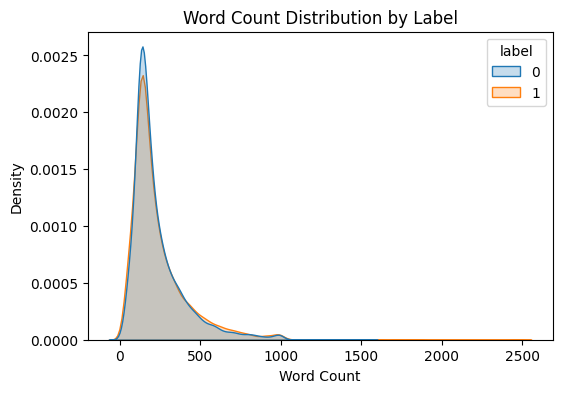

In [ ]:
#Length Distributions Comparisons - Positive vs Negative reviews

plt.figure(figsize=(6,4))
sns.kdeplot(data=train_df,x='word_count',hue='label',fill=True)
plt.title('Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.show()

Most of the reviews whether positive or negative,are relatively short , around 200 to 400 words.Since both the curves overlap, this is not a strong review of the label(0 or 1).Very few reviews exceed 1000 words.

**Outlier Detection:**

In [ ]:
#Identify Outliers

low_word_threshold = train_df['word_count'].quantile(0.01)
high_word_threshold = train_df['word_count'].quantile(0.99)

outliers_short = train_df[train_df['word_count'] <= low_word_threshold]
outliers_long = train_df[train_df['word_count'] >= high_word_threshold]

print("Very Short Reviews(bottom 1%)",outliers_short.shape[0])
print("Very long Reviews(top 1%)",outliers_long.shape[0])

print("\nExample of very short reviews")
print(outliers_short['review'].head(1).to_list())

print("\nExample of very long reviews")
print(outliers_long['review'].head(1).to_list())

Very Short Reviews(bottom 1%) 218
Very long Reviews(top 1%) 201

Example of very short reviews
['Great movie - especially the music - Etta James - "At Last". This speaks volumes when you have finally found that special someone.']

Example of very long reviews
['I\'m going to write about this movie and about "Irreversible" (the (in)famous scene in it). So you are warned, if you haven\'t seen the movie yet. This are just my thoughts, why I think the movie fails (in the end - pun intended).<br /><br />Acting wise, Rosario Dawson is really good and almost conveys portraying someone almost a decade younger (a teenager in other words). The villain guy is good, but loses his "evil" touch right before the end. If he really never changes, then why would he let a woman tie him up? He wouldn\'t, period. Then we also have the bartender/2nd rape Dude. Actually I don\'t think you would need him. At least not for the 2nd rape, but more about that later on.<br /><br />Let\'s reprise the story. Rosario

<Figure size 1200x500 with 0 Axes>

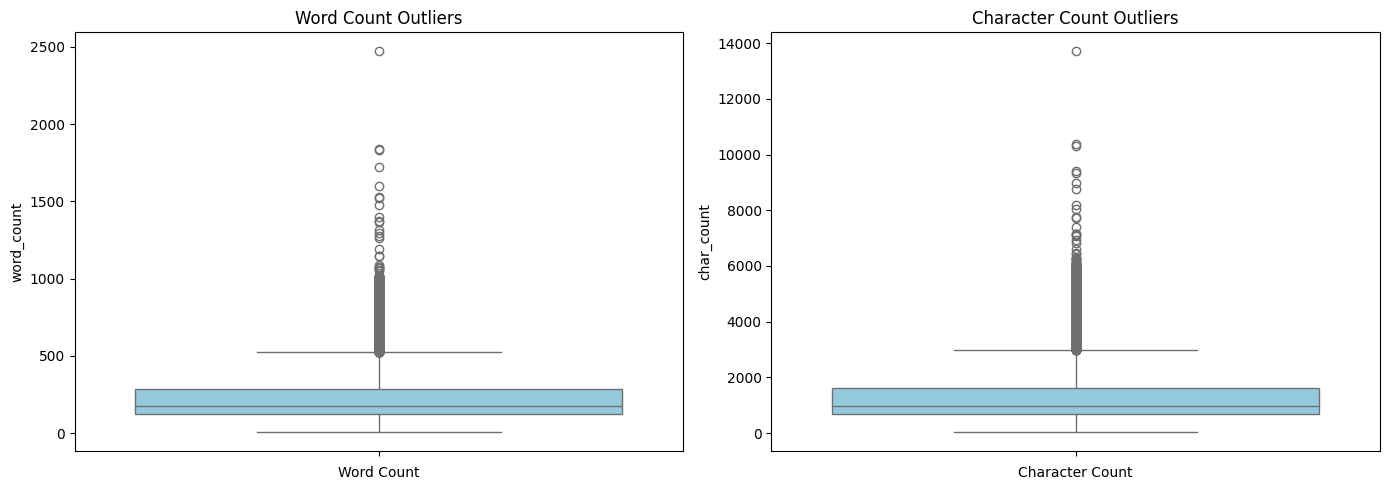

In [ ]:
plt.figure(figsize=(12,5))

fig,axes = plt.subplots(1,2,figsize=(14,5))

#Word Count Boxplot
sns.boxplot(y=train_df['word_count'],ax=axes[0],color='skyblue')
axes[0].set_title("Word Count Outliers")
axes[0].set_xlabel('Word Count')

#Character Count boxplot
sns.boxplot(y=train_df['char_count'],ax=axes[1],color='skyblue')
axes[1].set_title("Character Count Outliers")
axes[1].set_xlabel('Character Count')

plt.tight_layout()
plt.show()


Word Count Outlier plot reveals that most of the words were between ~50  and within ~500.Dots above the whiskers are outliers - reviews that are usually long up to 2500 words.It might have excessive repetition etc.

Character Count Outlier plot reveals the same structure like word count.Most reviews are under ~ 4000 characters.But ouliers stretch to 14000 characters. This might have html tags,punctuation etc. which will be removed during data processing.

#Vocabulary-Level EDA

/tmp/ipython-input-2436678500.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
/tmp/ipython-input-2436678500.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
/tmp/ipython-input-2436678500.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
/tmp/ipython-input-2436678500.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabe

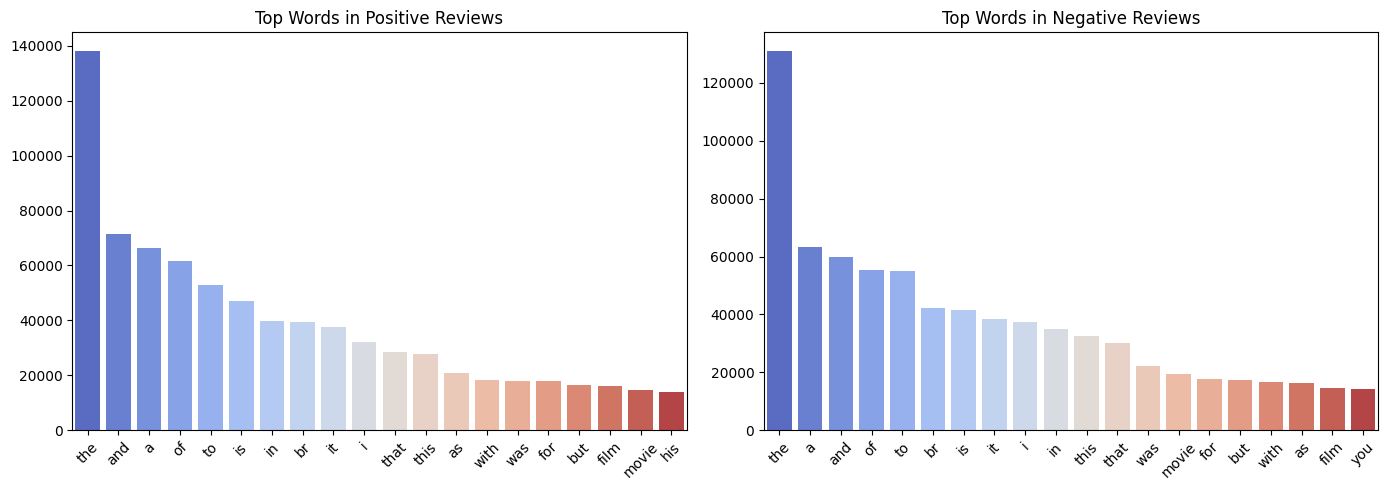

In [ ]:
#Most Frequent words(raw counts)
stop_words = set(stopwords.words('english'))

def tokenize(text):
  tokens = word_tokenize(text.lower())
  tokens = [t for t in tokens if t.isalpha()]

  return tokens
train_df['tokens'] = train_df['review'].apply(tokenize)

#Frequent words per class

def get_top_words_by_class(df,label,top_n=20):
  words = [word for tokens in df[df['label']==label]['tokens']for word in tokens]
  return Counter(words).most_common(top_n)

pos_words = get_top_words_by_class(train_df,1)
neg_words = get_top_words_by_class(train_df,0)

fig,axes = plt.subplots(1,2,figsize=(14,5))
for ax,data,title in zip(axes,[pos_words,neg_words],['Positive','Negative']):
  words,counts = zip(*data)
  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
  ax.set_title(f'Top Words in {title} Reviews')
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)

plt.tight_layout()
plt.show()

This shows the top frequent 20 words in Positive and Negative reviews.

From the above 2 plots,we can see that the word 'The' has maximum count for both positive and negative reviews.

/tmp/ipython-input-1370144885.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),palette='gray')


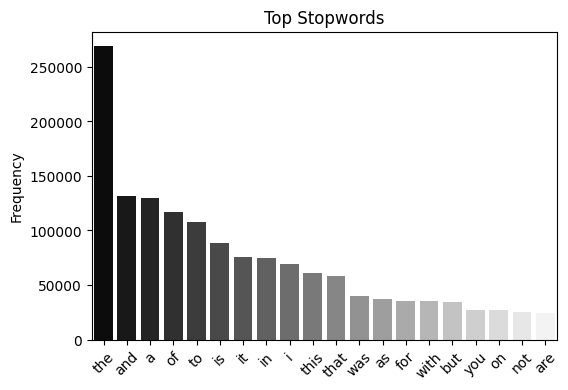

In [ ]:
#Stopword Frequency

train_df['tokens']

all_words = [word for tokens in train_df['tokens'] for word in tokens]
stopword_counts = Counter([word for word in all_words if word in stop_words])
top_stopwords = stopword_counts.most_common(20)
words,counts = zip(*top_stopwords)

plt.figure(figsize=(6,4))
sns.barplot(x=list(words),y=list(counts),palette='gray')
plt.title('Top Stopwords')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Rare words count

word_freq =  [word for tokens in train_df['tokens'] for word in tokens]
word_freq_list = Counter(word_freq)

rare_words = [word for word,count in word_freq_list.items() if count==1]
print(f"Total length of rare words: {len(rare_words)}")
print(f"Total Vocabulary size:{len(word_freq)}")

Total length of rare words: 24062
Total Vocabulary size:4609286


**Word Cloud:**

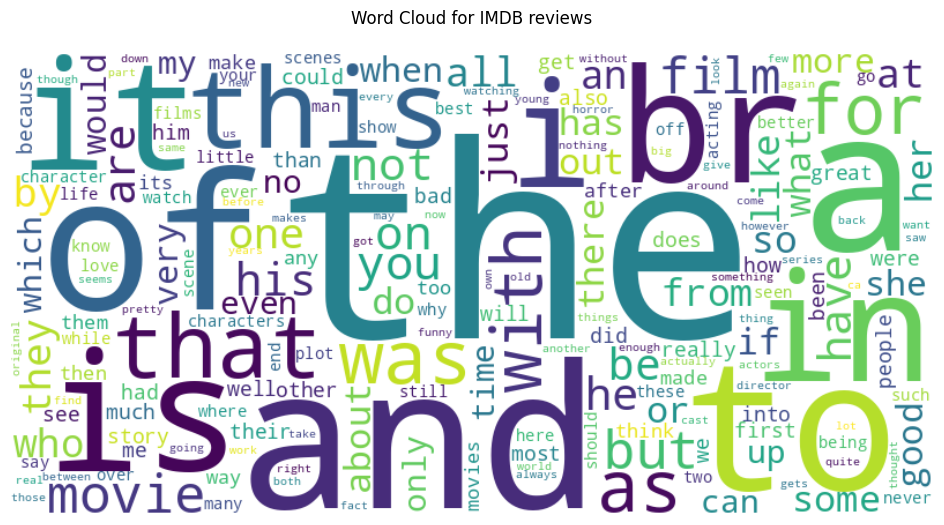

In [ ]:
word_freq = Counter(all_words)

wordcloud = WordCloud(width=800,height=400,background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for IMDB reviews\n")
plt.show()


**N-grams:**

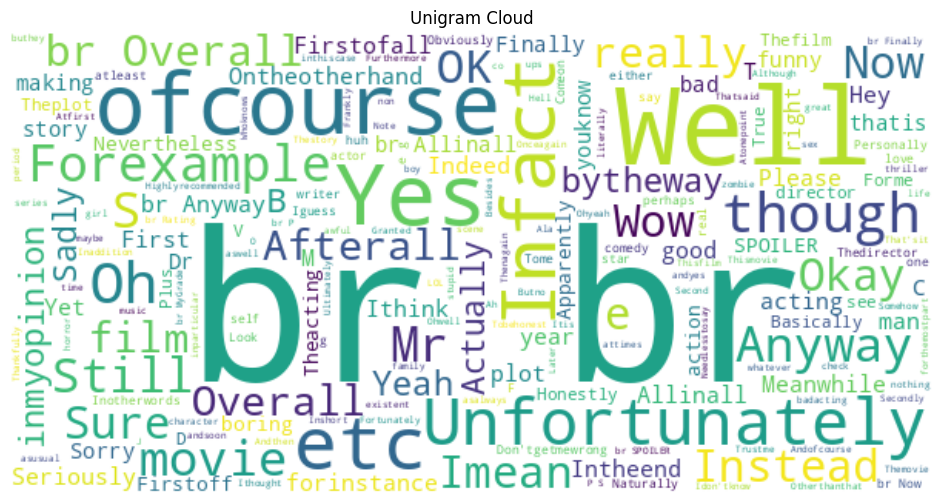

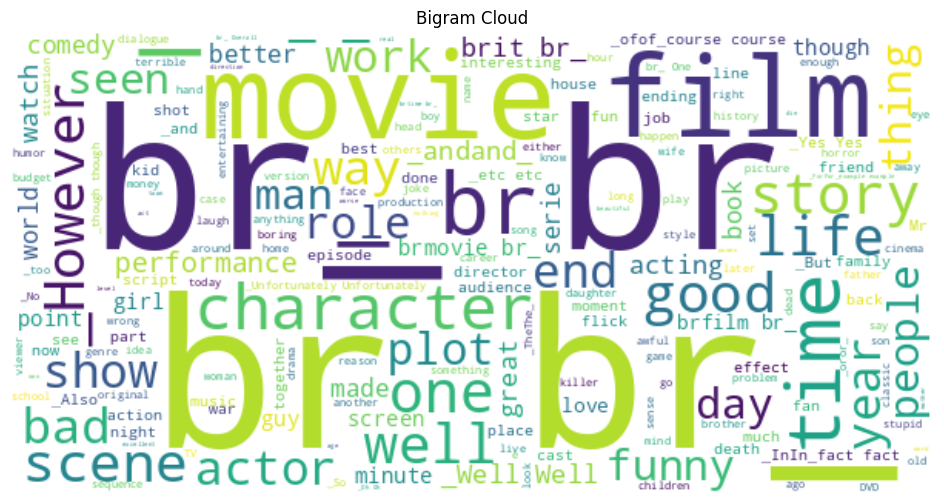

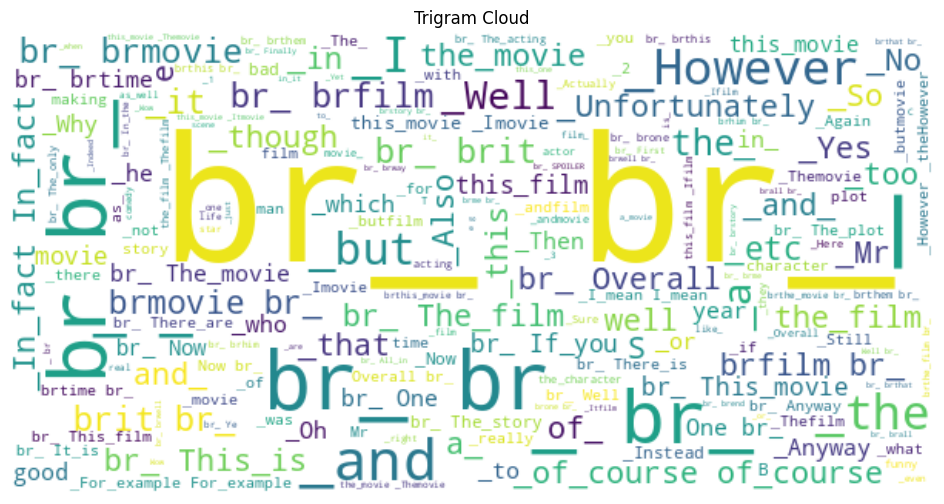

In [ ]:
#N-grams for the entire training dataset

def generate_ngrams(text,n):
  tokens = text.split()
  return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def generate_all_ngrams(series,n):
  all_ngrams = []
  for text in series:
    all_ngrams.extend(generate_ngrams(text,n))
  return all_ngrams

unigrams = generate_all_ngrams(train_df['review'],1)
bigrams = generate_all_ngrams(train_df['review'],2)
trigrams = generate_all_ngrams(train_df['review'],3)

unigram_counts = Counter(unigrams)
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

unigram_text = "".join(["_".join(u) for u in unigrams])
bigram_text = "".join(["_".join(b) for b in bigrams])
trigram_text = "".join(["_".join(t) for t in trigrams])

def show_cloud(text,title):
  wc = WordCloud(width=600,height=300,background_color='white').generate(text)
  plt.figure(figsize=(12,6))
  plt.imshow(wc,interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

show_cloud(unigram_text,"Unigram Cloud")
show_cloud(bigram_text,"Bigram Cloud")
show_cloud(trigram_text,"Trigram Cloud")

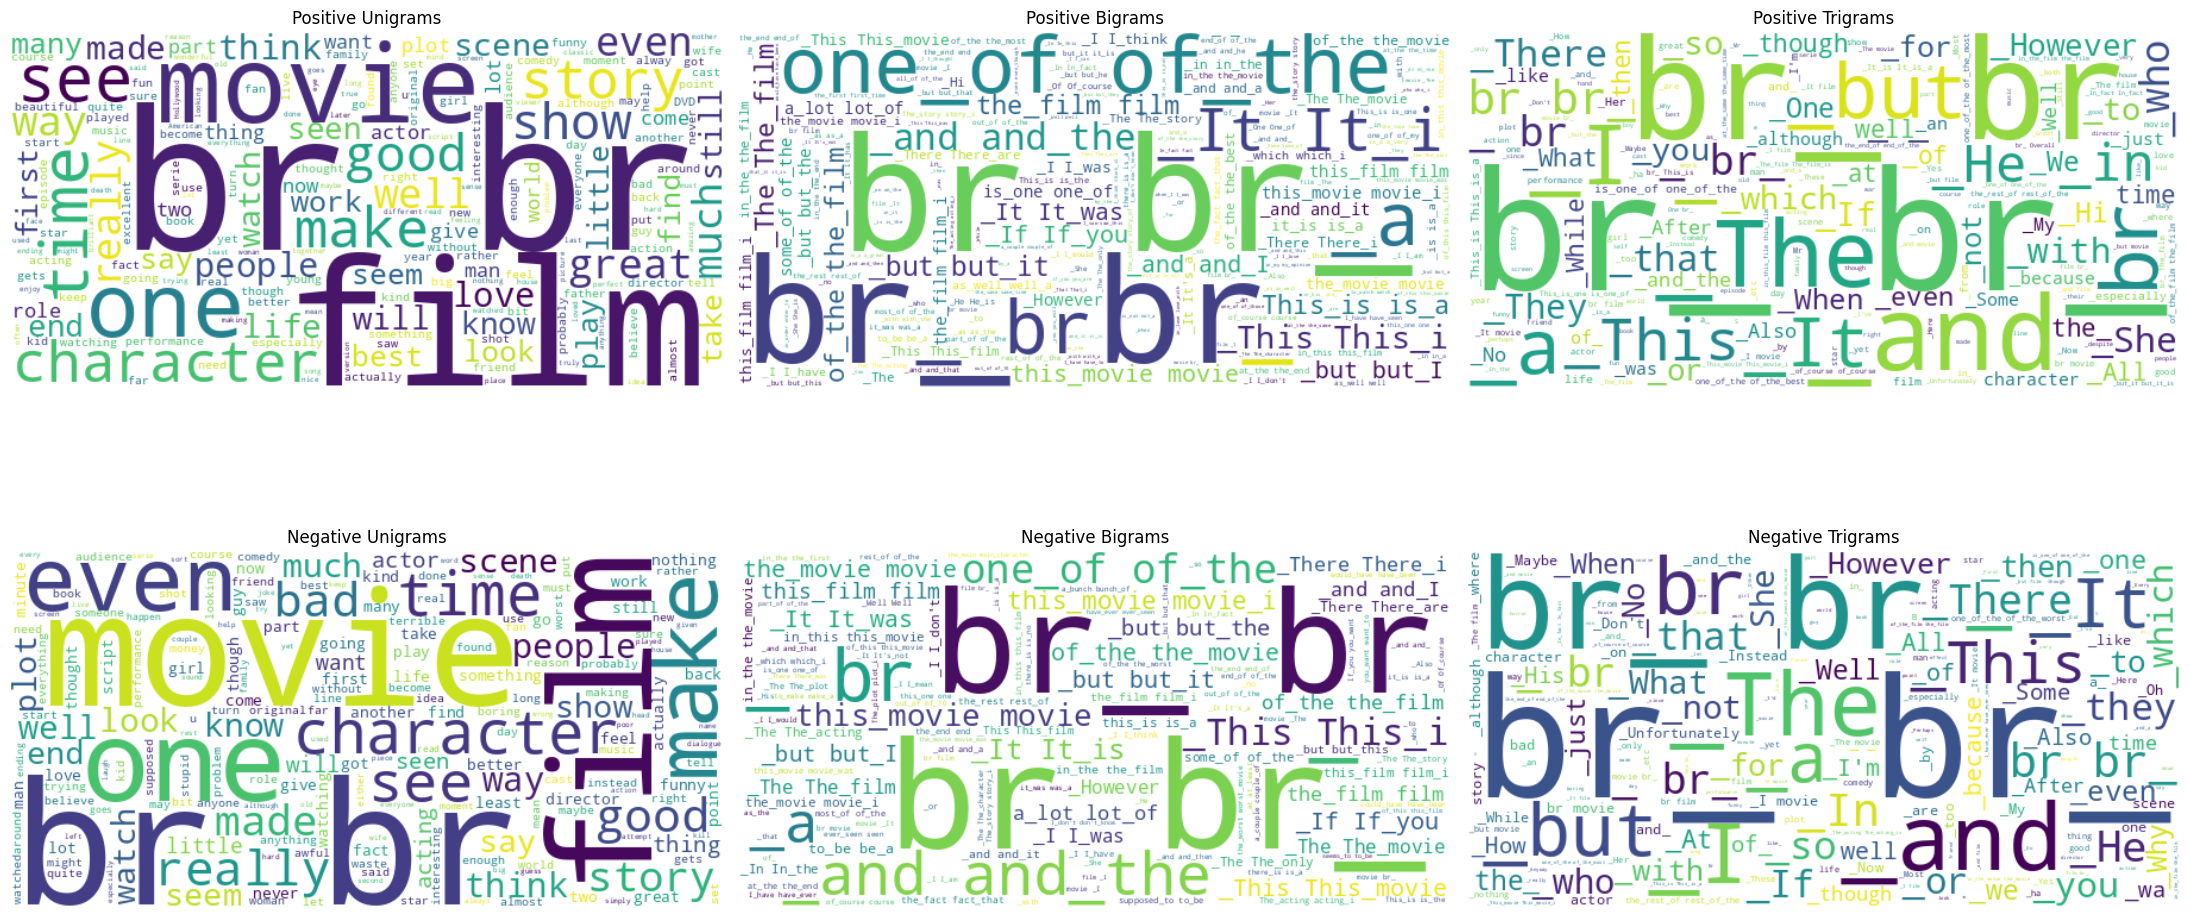

In [ ]:
#Separate N-grams for positive and negative reviews

pos_reviews = train_df[train_df['label']==1]['review']
neg_reviews = train_df[train_df['label']==0]['review']

def generate_ngrams(text,n):
  tokens = text.split()
  return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def generate_all_ngrams(series,n):
  all_ngrams = []
  for text in series:
    all_ngrams.extend(generate_ngrams(text,n))
  return all_ngrams

pos_unigrams = generate_all_ngrams(pos_reviews,1)
pos_bigrams = generate_all_ngrams(pos_reviews,2)
pos_trigrams = generate_all_ngrams(pos_reviews,3)

neg_unigrams = generate_all_ngrams(neg_reviews,1)
neg_bigrams = generate_all_ngrams(neg_reviews,2)
neg_trigrams = generate_all_ngrams(neg_reviews,3)

def ngrams_to_text(ngrams):
  return " ".join(["_".join(t) for t in ngrams])

pos_uni_text = ngrams_to_text(pos_unigrams)
pos_bi_text = ngrams_to_text(pos_bigrams)
pos_tri_text = ngrams_to_text(pos_trigrams)

neg_uni_text = ngrams_to_text(neg_unigrams)
neg_bi_text = ngrams_to_text(neg_bigrams)
neg_tri_text = ngrams_to_text(neg_trigrams)

def make_cloud(text):
  return WordCloud(width=600,height=300,background_color='white').generate(text)

fig,axes = plt.subplots(2,3,figsize=(22,12))

#Positive

axes[0,0].imshow(make_cloud(pos_uni_text),interpolation='bilinear')
axes[0,0].set_title("Positive Unigrams")
axes[0,0].axis("off")

axes[0,1].imshow(make_cloud(pos_bi_text),interpolation='bilinear')
axes[0,1].set_title("Positive Bigrams")
axes[0,1].axis("off")

axes[0,2].imshow(make_cloud(pos_tri_text),interpolation='bilinear')
axes[0,2].set_title("Positive Trigrams")
axes[0,2].axis("off")

#Negative

axes[1,0].imshow(make_cloud(neg_uni_text),interpolation='bilinear')
axes[1,0].set_title("Negative Unigrams")
axes[1,0].axis("off")

axes[1,1].imshow(make_cloud(neg_bi_text),interpolation='bilinear')
axes[1,1].set_title("Negative Bigrams")
axes[1,1].axis("off")

axes[1,2].imshow(make_cloud(neg_tri_text),interpolation='bilinear')
axes[1,2].set_title("Negative Trigrams")
axes[1,2].axis("off")

plt.tight_layout()
plt.show()


Top positive TF-IDF words:
br:0.1057
movie:0.0511
film:0.0508
great:0.0258
good:0.0254
like:0.0250
story:0.0233
just:0.0211
time:0.0205
really:0.0195
Top negative TF-IDF words:
br:0.1200
movie:0.0666
film:0.0483
bad:0.0323
just:0.0319
like:0.0314
good:0.0251
really:0.0228
time:0.0215
don:0.0214


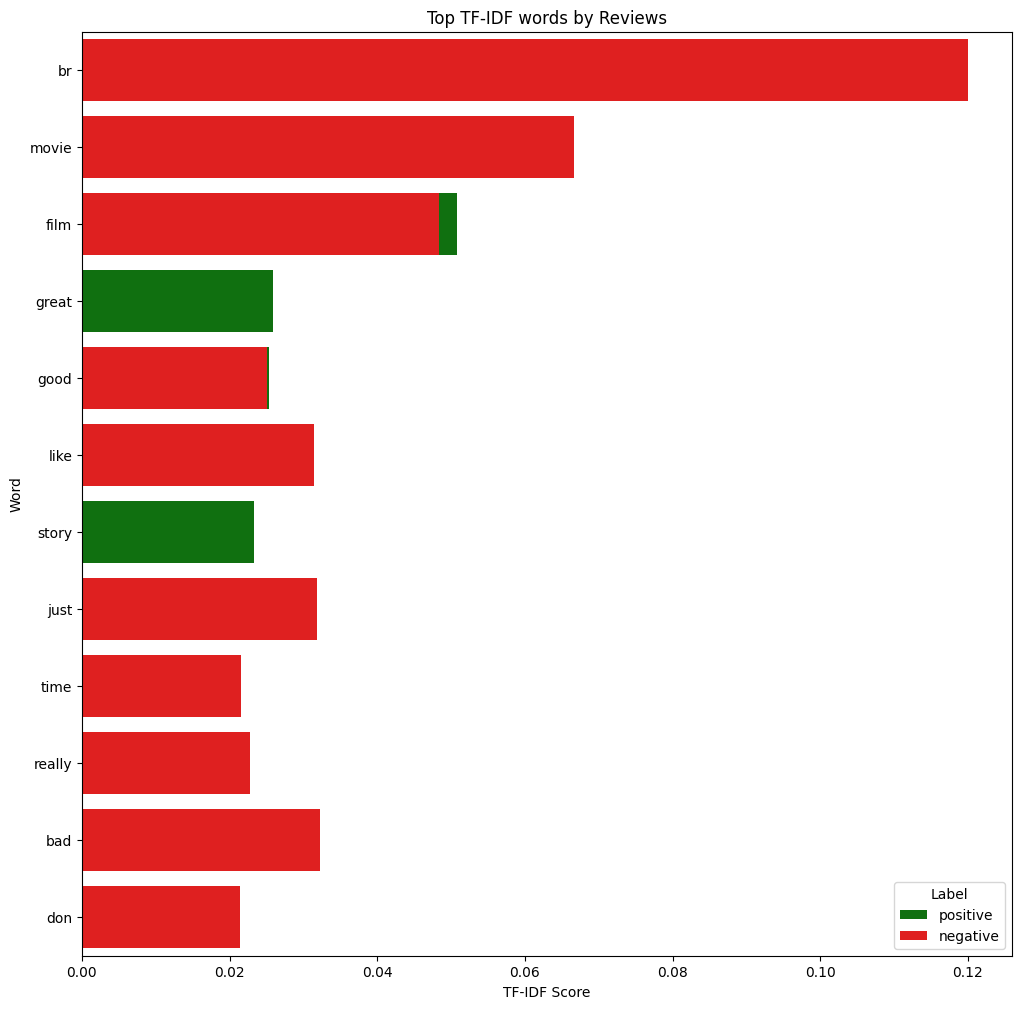

In [ ]:
#TF-IDF Visualisation

tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,1),stop_words='english')

X = tfidf.fit_transform(train_df['review'])
feature_names = tfidf.get_feature_names_out()

pos_idx = train_df['label']==1
neg_idx = train_df['label']==0

X_pos = X[pos_idx.values]
X_neg = X[neg_idx.values]

pos_mean = np.asarray(X_pos.mean(axis=0)).ravel()
neg_mean = np.asarray(X_neg.mean(axis=0)).ravel()

top_n = 10

pos_top_idx = pos_mean.argsort()[-top_n:][::-1]
neg_top_idx = neg_mean.argsort()[-top_n:][::-1]

pos_top_words = [(feature_names[i],pos_mean[i]) for i in pos_top_idx]
neg_top_words = [(feature_names[i],neg_mean[i]) for i in neg_top_idx]

print("Top positive TF-IDF words:")
for word,score in pos_top_words:
  print(f"{word}:{score:.4f}")

print("Top negative TF-IDF words:")
for word,score in neg_top_words:
  print(f"{word}:{score:.4f}")

#Heatmap

df_heat = pd.DataFrame({"word":[w for w,s in pos_top_words] + [w for w,s in neg_top_words],
                        "score":[s for w,s in pos_top_words] + [s for w,s in neg_top_words],
                        "Label":["positive"]*top_n+["negative"]*top_n})

plt.figure(figsize=(12,12))
sns.barplot(data=df_heat,y="word",x="score",hue="Label",dodge=False,palette=["green","red"])
plt.title("Top TF-IDF words by Reviews")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.show()

**EDA SUMMARY**

Reference:
keras tutorial
ciattion
https://www.geeksforgeeks.org/nlp/n-gram-in-nlp/

https://www.geeksforgeeks.org/deep-learning/keras-tuner-for-hyperparameter-optimization/

https://www.numberanalytics.com/blog/gru-text-classification

https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU

https://keras.io/api/layers/convolution_layers/convolution1d/

**Data Preprocessing and Cleaning:**

In [14]:
#Function to strip HTML tags and punctuations

def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  removed_html = tf.strings.regex_replace(lowercase,'<br/>','')
  #removed_html = tf.strings.regex_replace('[^A-Za-z]','')
  #removed_html = tf.strings.regex_replace("\s+",'')
  return tf.strings.regex_replace(removed_html,f'[{re.escape(string.punctuation)}]','')

max_features = 10000 #Maximum Vocabulary size
sequence_length = 250  #Pad reviews

#Create Vectorizer
vectorize_layer = TextVectorization(standardize = custom_standardization,
                                    max_tokens=max_features,
                                    output_mode='int',
                                    output_sequence_length=sequence_length)

#Adapt on Training text only
train_text = raw_train_ds.map(lambda x,y:x)
vectorize_layer.adapt(train_text)

#Apply vectorization to all datasets
def vectorize_text(text,label):
  text = tf.expand_dims(text,-1)
  return vectorize_layer(text),label

train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

#Optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Model Building and Interpretation:

# BaseLine Model:

In [ ]:
#Baseline Model:

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

model = keras.Sequential([layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
                          layers.GlobalAveragePooling1D(), #average all the wordvectorsin teh sequence
                          layers.Dense(16,activation='relu'), #learns hidden patterns(Non linear combinations)
                          layers.Dense(1,activation='sigmoid')]) #Output layer

#Compile the model

model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model

history = model.fit(train_ds,validation_data=val_ds,epochs=5)

#Evaluate
val_loss,val_acc = model.evaluate(val_ds)
print('Validation Accuracy',val_acc)
print('Validation Loss',val_loss)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.6164 - loss: 0.6392 - val_accuracy: 0.8312 - val_loss: 0.3907
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8526 - loss: 0.3479 - val_accuracy: 0.8338 - val_loss: 0.3641
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8884 - loss: 0.2734 - val_accuracy: 0.8500 - val_loss: 0.3415
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9065 - loss: 0.2330 - val_accuracy: 0.8598 - val_loss: 0.3306
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9209 - loss: 0.2045 - val_accuracy: 0.8788 - val_loss: 0.3075
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8595 - loss: 0.3426
Test Accuracy 0.8590400218963623
Test Loss 0.3395450711250305


**Evaluation Metrics (Baseline Model):**

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8595 - loss: 0.3426
Test Accuracy 0.8590400218963623
Test Loss 0.3395450711250305
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

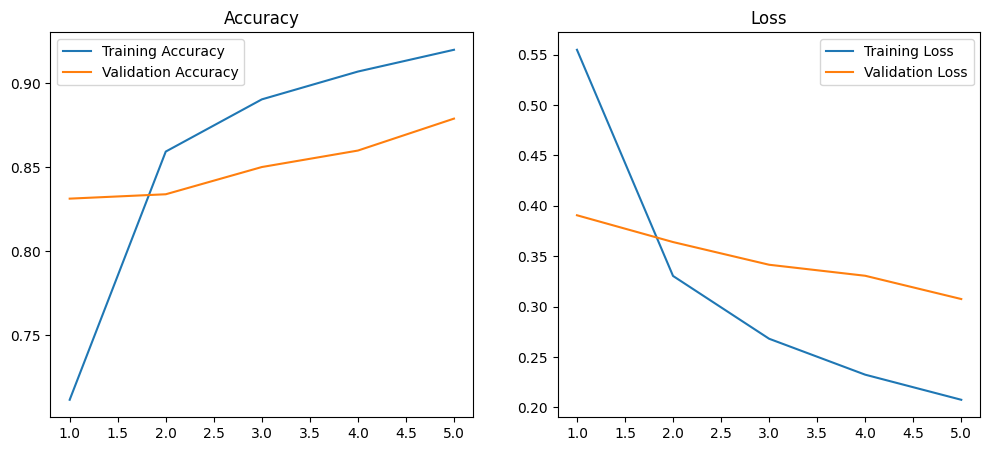

In [ ]:
#Baseline Evaluation Metrics
val_loss_baseline,val_acc_baseline = model.evaluate(val_ds)
print('Validation Accuracy',val_acc_baseline)
print('Validation Loss',val_loss_baseline)

y_true_baseline=[]
y_pred_baseline=[]

for text_batch,label_batch in val_ds:
  preds = model.predict(text_batch)
  y_true_baseline.extend(label_batch.numpy())
  y_pred_baseline.extend((preds>0.5).astype('int32'))

cm_baseline = confusion_matrix(y_true_baseline,y_pred_baseline)
print(cm_baseline)

print(classification_report(y_true_baseline,y_pred_baseline))

history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()


**Baseline Summary:**

The accuracy of the baseline model is 0.85 which is good for a baseline model.This can be used as a benchmark to compare with the other models.

Model is good at identifying negative reviews than positive reviews.(TN - )Likely to Miss positive reviews(Higher FN)

This is confirmed in the classification Report summary.Negative reviews have higher recall and F1 score than the positive reviews (0 - 0.86, 1 - 0.84)

**Acccuracy Plot:**

Training accuracy climbs steadily after 0.85 and it reaches 0.925.Validation accuracy reaches around 0.85.Looks like overfitting which is natural for baseline model.

**Loss Plot:**

Training Loss is very high initially and then decreases.
Validation loss remains around 0.3 which confirms the overfitting pattern.

Baseline models overfits which is normal and this can be used as a base for other models.

# BiLSTM:

BiLSTM captures the information both forward and backward thereby capturing more contextual information.It is good at capturing negation,contrast etc.(like 'Not Good').

In [ ]:
#Used the same parameters I have used in baseline for comparison

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#BiLSTM model
bilstm_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
                          layers.Bidirectional(layers.LSTM(64,return_sequences=False)) ,
                          layers.Dense(32,activation='relu'), #learns hidden patterns(Non linear combinations)
                          layers.Dense(1,activation='sigmoid')]) #Output layer

bilstm_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model

history_bilstm = bilstm_model.fit(train_ds,validation_data=val_ds,epochs=5)

#Evaluate
val_loss_bilstm,val_acc_bilstm = bilstm_model.evaluate(val_ds)
print('Val Accuracy',val_acc_bilstm)
print('Val Loss',val_loss_bilstm)



Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 187s 291ms/step - accuracy: 0.6590 - loss: 0.5877 - val_accuracy: 0.6936 - val_loss: 0.5733
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 179s 287ms/step - accuracy: 0.8381 - loss: 0.3749 - val_accuracy: 0.8152 - val_loss: 0.4281
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 179s 287ms/step - accuracy: 0.9031 - loss: 0.2558 - val_accuracy: 0.8460 - val_loss: 0.3630
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 180s 287ms/step - accuracy: 0.9332 - loss: 0.1917 - val_accuracy: 0.8548 - val_loss: 0.3721
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 288ms/step - accuracy: 0.9509 - loss: 0.1446 - val_accuracy: 0.8434 - val_loss: 0.4001
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.8193 - loss: 0.4648
Test Accuracy 0.8162000179290771
Test Loss 0.4713023900985718


In [ ]:
#Used the same parameters I have used in baseline for comparison
#Due to overfitting, have added regularization

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#BiLSTM model
bilstm_model_1 = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.3),

    layers.Bidirectional(layers.LSTM(32,dropout=0.3,recurrent_dropout=0.3)) ,
    layers.Dense(32,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

bilstm_model_1.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
#Train Model

history_bilstm_1 = bilstm_model_1.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop])

#Evaluate
val_loss_bilstm_1,val_acc_bilstm_1 = bilstm_model_1.evaluate(val_ds)
print('Test Accuracy',val_acc_bilstm_1)
print('Test Loss',val_loss_bilstm_1)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 479ms/step - accuracy: 0.6090 - loss: 0.6435 - val_accuracy: 0.7832 - val_loss: 0.4797
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 469ms/step - accuracy: 0.7864 - loss: 0.4821 - val_accuracy: 0.7570 - val_loss: 0.4883
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 323s 471ms/step - accuracy: 0.8125 - loss: 0.4345 - val_accuracy: 0.7676 - val_loss: 0.4782
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 472ms/step - accuracy: 0.8521 - loss: 0.3719 - val_accuracy: 0.6958 - val_loss: 0.6415
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 295s 472ms/step - accuracy: 0.7990 - loss: 0.4418 - val_accuracy: 0.8138 - val_loss: 0.4223
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 295s 472ms/step - accuracy: 0.8634 - loss: 0.3490 - val_accuracy: 0.8090 - val_loss: 0.4356
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 468ms/step - accuracy: 0.8832 - loss: 0.2969 - val_accuracy: 0.8214 - val_loss: 0.4211
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 296s 473ms/step - accuracy: 0.8941 - loss: 0.27

In [ ]:
#Training Curve:

#BiLSTM Training Curve

acc_bilstm = history_bilstm.history['accuracy']
val_acc_bilstm = history_bilstm.history['val_accuracy']
loss_bilstm = history_bilstm.history['accuracy']
val_loss_bilstm = history_bilstm.history['val_loss']

epochs_bilstm = range(1,len(acc)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Val Accuracy')
plt.title('BiLSTM: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Val Loss')
plt.title('BiLSTM: Loss')
plt.legend()
plt.show()

In [ ]:
#Evaluation Metric:

#Classification Report
y_true_bilstm = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_bilstm = bilstm_model.predict(val_ds)
y_pred_bilstm = (y_pred_probs_bilstm > 0.5).astype("int32")

print(classification_report(y_true_bilstm, y_pred_bilstm))

#Confusion Matrix

cm_bilstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_bilstm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix")
plt.show()

In [ ]:
#Hyperparameter Tuning BiLSTM

def build_model_bilstm(bilstm):
    # 1. Tune the number of units in the LSTM layer
    # Choose an optimal value between 32-128
    bilstm_units = bilstm.Int('units', min_value=32, max_value=128, step=32)

    # 2. Tune the dropout rate
    bilstm_dropout = bilstm.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)

    # 3. Tune the learning rate
    bilstm_learning_rate = bilstm.Choice('learning_rate', values=[1e-3, 1e-4])

    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
        layers.SpatialDropout1D(0.3),

        # Removed recurrent_dropout for CuDNN speed
        layers.Bidirectional(layers.LSTM(units=bilstm_units, dropout=bilstm_dropout)),

        layers.Dense(bilstm_units, activation='relu'),
        layers.Dropout(bilstm_dropout),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=bilstm_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the Tuner (Hyperband is efficient)
tuner_bilstm = kt.Hyperband(
    build_model_bilstm,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='imdb_bilstm_tuning'
)

# Early stopping to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Start searching
tuner_bilstm.search(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])

# Get the best model
best_model_bilstm = tuner_bilstm.get_best_models(num_models=1)[0]



Trial 30 Complete [00h 01m 22s]
val_accuracy: 0.8690000176429749

Best val_accuracy So Far: 0.8772000074386597
Total elapsed time: 00h 27m 18s


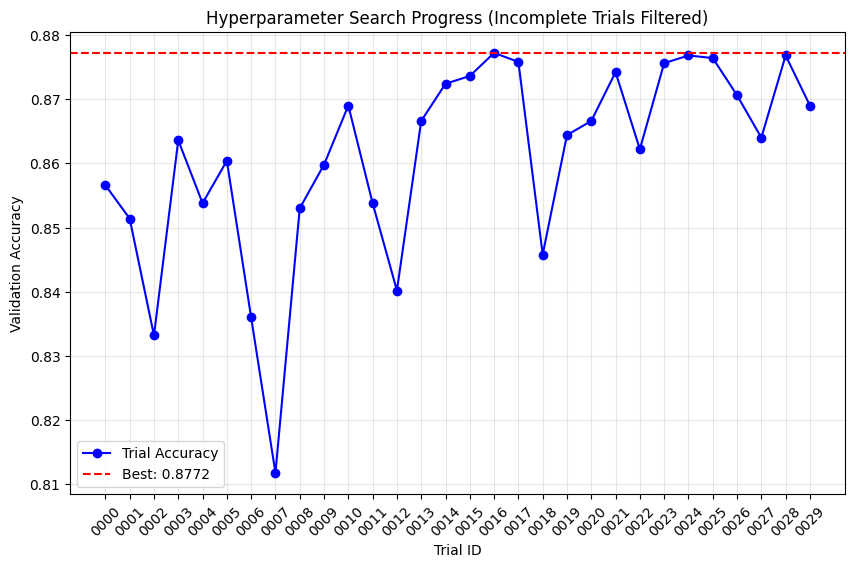

In [ ]:
# 1. Get all trials from the oracle
all_trials = tuner_bilstm.oracle.trials.values()

# 2. Filter out trials that were interrupted (score is None)
complete_trials = [t for t in all_trials if t.score is not None]

# 3. Sort them by Trial ID so the graph follows the timeline
complete_trials.sort(key=lambda x: int(x.trial_id))

# 4. Extract IDs and Scores
trial_ids = [t.trial_id for t in complete_trials]
trial_scores = [t.score for t in complete_trials]

# 5. Plot
plt.figure(figsize=(10, 6))
plt.plot(trial_ids, trial_scores, marker='o', linestyle='-', color='b', label='Trial Accuracy')
plt.axhline(y=max(trial_scores), color='r', linestyle='--', label=f'Best: {max(trial_scores):.4f}')
plt.title('Hyperparameter Search Progress')
plt.xlabel('Trial ID')
plt.ylabel('Validation Accuracy')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Evaluation Metric for the best model


best_model_bilstm = tuner_bilstm.get_best_models(num_models=1)[0]

y_true_bilstm_tuned = np.concatenate([y for x,y in test_ds],axis=0)
y_pred_probs_bilstm_tuned = best_model_bilstm.predict(test_ds)
y_pred_bilstm_tuned = (y_pred_probs_bilstm_tuned > 0.5).astype("int32")

print("=== Final Evaluation Report: BiLSTM Model===")
print(classification_report(y_true_bilstm_tuned,y_pred_bilstm_tuned,target_names=['Negative','Positive']))

#Best Hyperparameters

best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]


782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
=== Final Evaluation Report: BiLSTM Model===
              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86     12500
    Positive       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000




 === Optimized Best Hyperparameters ===
LSTM Units: 128
Dropout Rate: 0.2
Learning Rate: 0.0001


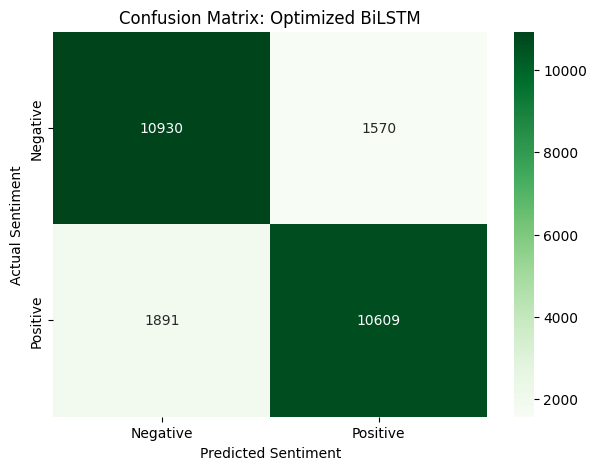

In [ ]:
print("\n === Optimized Best Hyperparameters ===")
print(f"LSTM Units: {best_hps_bilstm.get('units')}")
print(f"Dropout Rate: {best_hps_bilstm.get('dropout')}")
print(f"Learning Rate: {best_hps_bilstm.get('learning_rate')}")

#Confusion Matrix

cm_bilstm_tuned = confusion_matrix(y_true_bilstm_tuned, y_pred_bilstm_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_bilstm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix: Optimized BiLSTM')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

# 1D CNN:
While BiLSTM reads word by word in both the directions,1D CNN uses filers to slide across the sentence to pick the patterns.

**Architecture:**

*   Embedding Layer - Turns words into vectors
*   Convolution Layer - Learns local patters(n-grams)
*   Global MaxPooling - Pickts the most important feature from the window
*   Dense Layer - To learn complex patterns
*   Dropout - Reduce overfitting
*   Dense Layer - Makes the final prediction



In [ ]:
#1DCNN

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#1DCNN model
cnn_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.2),
    layers.Conv1D(filters=64,kernel_size=5,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)) ,
    layers.GlobalMaxPooling1D(),
    layers.Dense(64,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

cnn_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
early_stop_cnn = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2)
history_cnn = cnn_model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop_cnn])
cnn_model.summary()

#Evaluate
val_loss_cnn,val_acc_cnn = cnn_model.evaluate(val_ds)
print('CNN Test Accuracy',val_acc_cnn)
print('CNN Test Loss',val_loss_cnn)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6231 - loss: 0.6511 - val_accuracy: 0.8372 - val_loss: 0.4021
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8586 - loss: 0.3650 - val_accuracy: 0.8550 - val_loss: 0.3761
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9216 - loss: 0.2447 - val_accuracy: 0.8690 - val_loss: 0.3857
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9594 - loss: 0.1602 - val_accuracy: 0.8682 - val_loss: 0.4224


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 250, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 246, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,914,309 (14.93 MB)

 Trainable params: 1,304,769 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,609,540 (9.95 MB)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8590 - loss: 0.4434
CNN Test Accuracy 0.8571199774742126
CNN Test Loss 0.44352027773857117


The 1D CNN model show signs of overfitting .The training loss starts at 0.65 and decreases to 0.16 while the validation loss increases from 0.42 to 0.40.This indicates that the model begins to capture noise specific to the training set rather than broad sentiment patterns.

Early stopping is used to stop at the moment the validation loss starts improving.

Next,I am going to use keras Tuner find the best set of hyperparameters of 1D CNN model.



*   Spatial Dropout - 0.1,0.2,0.3,0.4

*   Filters = 32,64,96,128
*   Kernel_size = 3,5,7


*   List item



In [ ]:
#1DCNN Training Curve

acc_cnn = history_cnn.history['accuracy']
val_acc_cnn = history_cnn.history['val_accuracy']
loss_cnn = history_cnn.history['accuracy']
val_loss_cnn = history_cnn.history['val_loss']

epochs = range(1,len(acc)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('1DCNN: Loss')
plt.legend()
plt.show()


In [ ]:
#Classification Report
y_true_cnn = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_cnn = cnn_model.predict(val_ds)
y_pred_cnn = (y_pred_probs_cnn > 0.5).astype("int32")

print(classification_report(y_true_cnn, y_pred_cnn))

#Confusion Matrix

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
#nOT NEEDED


#Hyperparameter Tuning - Objective - Val_Accuracy

def build_cnn_hypermodel(cnn):
    model = keras.Sequential()

    # Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=cnn.Float('spatial_dropout', min_value=0.1, max_value=0.4, step=0.1)
    ))

    #Conv1D Filters and Kernel Size
    model.add(layers.Conv1D(
        filters=cnn.Int('filters', min_value=32, max_value=128, step=32),
        kernel_size=cnn.Choice('kernel_size', values=[3, 5, 7]),
        activation='relu'
    ))

    model.add(layers.GlobalMaxPooling1D())

    #Dense Layer Units
    model.add(layers.Dense(
        units=cnn.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))

    model.add(layers.Dropout(cnn.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))

    #Learning Rate
    lr = cnn.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.Hyperband(
    build_cnn_hypermodel,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='cnn_tuning_dir',
    project_name='imdb_cnn_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

tuner.search(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal Filters: {best_hps.get('filters')}")
print(f"Optimal Kernel Size: {best_hps.get('kernel_size')}")
print(f"Optimal Spatial Dropout: {best_hps.get('spatial_dropout')}")

# Build the model with the best hyperparameters and train it
best_cnn_model = tuner.hypermodel.build(best_hps)
history = best_cnn_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])



Trial 30 Complete [00h 00m 28s]
val_accuracy: 0.871399998664856

Best val_accuracy So Far: 0.8773999810218811
Total elapsed time: 00h 06m 05s
Optimal Filters: 64
Optimal Kernel Size: 5
Optimal Spatial Dropout: 0.2
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6386 - loss: 0.6020 - val_accuracy: 0.8516 - val_loss: 0.3443
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8752 - loss: 0.3041 - val_accuracy: 0.8702 - val_loss: 0.3156
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9407 - loss: 0.1648 - val_accuracy: 0.8780 - val_loss: 0.3277
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9766 - loss: 0.0768 - val_accuracy: 0.8648 - val_loss: 0.4186


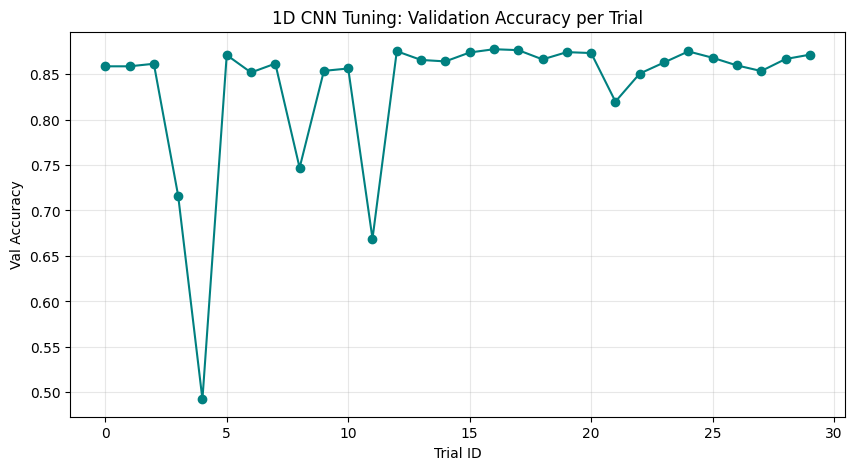

In [ ]:

#NOT NEEDED


#Plot Validation accuracy of all trials

all_trials = tuner.oracle.trials.values()
trial_ids = [int(t.trial_id) for t in all_trials if t.score is not None]
trial_scores = [t.score for t in all_trials if t.score is not None]

sorted_data = sorted(zip(trial_ids, trial_scores))
ids, scores = zip(*sorted_data)

plt.figure(figsize=(10, 5))
plt.plot(ids, scores, marker='o', linestyle='-', color='teal')
plt.title('1D CNN Tuning: Validation Accuracy per Trial')
plt.xlabel('Trial ID')
plt.ylabel('Val Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6342 - loss: 0.6093 - val_accuracy: 0.8468 - val_loss: 0.3634
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8721 - loss: 0.3149 - val_accuracy: 0.8708 - val_loss: 0.3096
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9337 - loss: 0.1823 - val_accuracy: 0.8706 - val_loss: 0.3345
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9721 - loss: 0.0895 - val_accuracy: 0.8688 - val_loss: 0.3996
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9889 - loss: 0.0399 - val_accuracy: 0.8652 - val_loss: 0.4701
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9927 - loss: 0.0247 - val_accuracy: 0.8632 - val_loss: 0.5506
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9934 - loss: 0.0208 - val_accuracy: 0.8730 - val_loss: 0.5811
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9939 - loss: 0.0180 - val_accuracy: 0.

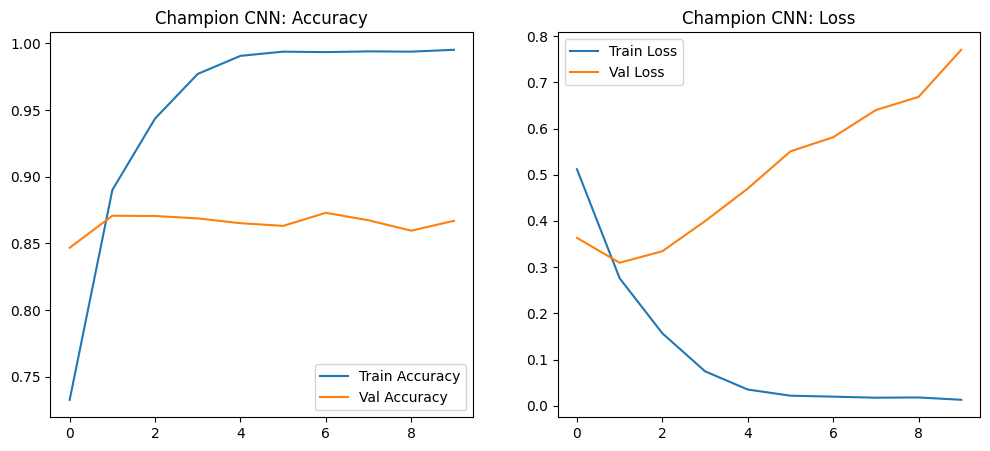

In [ ]:
#NOT NEEDED
best_=hps = tuner.get_best_hyperparameters(num_trials=1)[0]

champion_model = tuner.hypermodel.build(best_hps)
history = champion_model.fit(train_ds, validation_data=val_ds, epochs=10)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Champion CNN: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Champion CNN: Loss')
plt.legend()

plt.show()

## **Analysis:**

**Accuracy Graph**

*   Training accuracy starts very low and becomes closer to 1 by last epochs.
*   Validation accuracy begina at 85% , briefly increases a bit to 87% and then almost remains the same till the last epochs.
*   This means that the model is memorizing and it will work only on the training data and not on the unseen validation data.

**Loss Graph:**

*   Training Loss decreases rapidly from 0.5 to near ~0 , which shows almost perfect training accuracy.
*   Validation loss, on the other hand, starts low and then increases across epochs, confirming that additional training will increase it further.
*   This indicates a sign of overfitting.

Keras Tuner gave the best possible hyperparamater combination based on the highest Validation accuracy.But from the above 2 plots, we found that there is a classic sign of overfitting.So, picking the epoch with the lowest validation loss which tells when to stop training for a given hyperparameter set.






In [ ]:
#In the same hyperparameter tuning I used earlier, am going to change the objective to val_loss

def build_cnn_hypermodel(cnn):
    model = keras.Sequential()

    #Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=cnn.Float('spatial_dropout', min_value=0.1, max_value=0.4, step=0.1)
    ))

    #Conv1D Filters and Kernel Size
    model.add(layers.Conv1D(
        filters=cnn.Int('filters', min_value=32, max_value=128, step=32),
        kernel_size=cnn.Choice('kernel_size', values=[3, 5, 7]),
        activation='relu'
    ))

    model.add(layers.GlobalMaxPooling1D())

    #Dense Layer Units
    model.add(layers.Dense(
        units=cnn.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))

    model.add(layers.Dropout(cnn.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))


#Learning Rate
    lr = cnn.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_cnn = kt.Hyperband(
    build_cnn_hypermodel,
    objective='val_loss',
    max_epochs=10,
    factor=3,
    directory='cnn_tuning_dir',
    project_name='imdb_cnn_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

tuner_cnn.search(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])

# Get the best hyperparameters
best_hps_cnn = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal Filters: {best_hps_cnn.get('filters')}")
print(f"Optimal Kernel Size: {best_hps_cnn.get('kernel_size')}")
print(f"Optimal Spatial Dropout: {best_hps_cnn.get('spatial_dropout')}")

# Build the model with the best hyperparameters and train it
best_cnn_model = tuner_cnn.hypermodel.build(best_hps_cnn)
history_cnn = best_cnn_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])


Trial 30 Complete [00h 00m 28s]
val_loss: 0.3130100667476654

Best val_loss So Far: 0.3098360598087311
Total elapsed time: 00h 06m 32s
Optimal Filters: 96
Optimal Kernel Size: 7
Optimal Spatial Dropout: 0.30000000000000004
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5120 - loss: 0.6928 - val_accuracy: 0.6202 - val_loss: 0.6895
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5965 - loss: 0.6799 - val_accuracy: 0.6884 - val_loss: 0.5889
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7447 - loss: 0.5386 - val_accuracy: 0.8038 - val_loss: 0.4356
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8238 - loss: 0.4031 - val_accuracy: 0.8352 - val_loss: 0.3742
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8634 - loss: 0.3337 - val_accuracy: 0.8516 - val_loss: 0.3425
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8847 - loss: 0.2861 - val_accuracy: 0.8634 - val_loss: 0.3230
Epoch 7/1

In [ ]:
#Get best hyperparameters from tuner
best_hps_cnn = tuner.get_best_hyperparameters(num_trials=1)[0]

#uild and train a model with hyperparameters
best_model_cnn = tuner.hypermodel.build(best_hps_cnn)

history_cnn = best_model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,              # or more, with EarlyStopping if you like
    callbacks=[stop_early]
)

#val_loss and corresponding val_accuracy
val_loss_history_cnn = history.history["val_loss"]
val_acc_history_cnn  = history.history["val_accuracy"]

best_epoch_cnn = int(np.argmin(val_loss_history_cnn))  # index of lowest val_loss
best_val_loss_cnn = float(val_loss_history_cnn[best_epoch])
best_val_acc_cnn  = float(val_acc_history_cnn[best_epoch])

print("Best epoch:", best_epoch_cnn + 1)
print("Best val_loss:", best_val_loss_cnn)
print("Best val_accuracy:", best_val_acc_cnn)


cnn_result = {
    "model_name": "1D_CNN_tuned",
    "best_epoch": best_epoch_cnn + 1,
    "best_val_loss": best_val_loss,
    "best_val_accuracy": best_val_acc_cnn,
    "filters": best_hps_cnn.get("filters"),
    "kernel_size": best_hps_cnn.get("kernel_size"),
    "spatial_dropout": best_hps_cnn.get("spatial_dropout"),
    "dense_units": best_hps_cnn.get("dense_units"),
    "dropout": best_hps_cnn.get("dropout"),
    "learning_rate": best_hps_cnn.get("learning_rate"),
}

print(cnn_result)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5046 - loss: 0.6935 - val_accuracy: 0.6094 - val_loss: 0.6899
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5892 - loss: 0.6847 - val_accuracy: 0.6924 - val_loss: 0.6079
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7336 - loss: 0.5591 - val_accuracy: 0.7992 - val_loss: 0.4456
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8149 - loss: 0.4170 - val_accuracy: 0.8378 - val_loss: 0.3771
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8599 - loss: 0.3399 - val_accuracy: 0.8584 - val_loss: 0.3444
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8843 - loss: 0.2910 - val_accuracy: 0.8652 - val_loss: 0.3246
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9013 - loss: 0.2524 - val_accuracy: 0.8690 - val_loss: 0.3124
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9158 - loss: 0.2193 - val_accuracy: 0.8744 - val

In [ ]:
#1DCNN Hyperparameter Tuned Training Curve

acc_cnn_tuned = history_cnn.history['accuracy']
val_acc_cnn_tuned = history_cnn.history['val_accuracy']
loss_gru = history_cnn.history['accuracy']
val_loss_gru = history_cnn.history['val_loss']

epochs = range(1,len(acc)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('1DCNN: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('1DCNN: Loss')
plt.legend()
plt.show()


# Evaluation Metrics:

In [ ]:
y_true_cnn_tuned = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_cnn_tuned = best_model_cnn.predict(val_ds)
y_pred_cnn_tuned = (y_pred_probs_cnn_tuned > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true_cnn_tuned, y_pred_cnn_tuned))

# Confusion Matrix
cm_cnn_tuned = confusion_matrix(y_true_cnn_tuned, y_pred_cnn_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn_tuned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#ROC AUC Curve

fpr_cnn_tuned, tpr_cnn_tuned, thresholds_cnn_tuned = roc_curve(y_true_cnn_tuned, y_pred_probs_cnn_tuned)
roc_auc_cnn_tuned = auc(fpr_cnn_tuned, tpr_cnn_tuned)

plt.figure(figsize=(6,4))
plt.plot(fpr_cnn_tuned, tpr_cnn_tuned, label=f"AUC = {roc_auc_cnn_tuned:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

NameError: name 'np' is not defined

1D CNN Summary:



*   Based on the chosen architecture, I first built a 1D‑CNN model and evaluated its performance using validation accuracy. The results indicated clear signs of overfitting.

*   Next, I used Keras Tuner to search for optimal hyperparameters using validation accuracy as the objective.
*   Although the tuner identified a configuration with improved validation accuracy, the training curves still showed overfitting.


*   To address this, I ran Keras Tuner again—this time optimizing for validation loss instead of accuracy. This approach produced a more stable model with better generalization.

*   Using the best hyperparameters identified through the val_loss‑based search, the following section summarizes the optimal hyperparameter combination and provides a brief performance report.
*   Best epoch: 8
Best val_loss: 0.30746176838874817
Best val_accuracy: 0.8744000196456909

{'model_name': '1D_CNN_tuned', 'best_epoch': 8, 'best_val_loss': 0.30746176838874817, 'best_val_accuracy': 0.8744000196456909, 'filters': 96, 'kernel_size': 7, 'spatial_dropout': 0.30000000000000004, 'dense_units': 128, 'dropout': 0.2, 'learning_rate': 0.0001}










# Gated Recurrent Networks: (GRU)

In [11]:
vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#GRU model
gru_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),

    GRU(64,dropout=0.2,recurrent_dropout=0.2),
    Dense(1,activation='sigmoid')
])

gru_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
history_gru = gru_model.fit(train_ds,validation_data=val_ds,epochs=10,batch_size=64,callbacks=[stop_early])
gru_model.summary()

#Evaluate
val_loss_gru,val_acc_gru = gru_model.evaluate(val_ds)
print('CNN Val Accuracy',val_acc_gru)
print('CNN Val Loss',val_loss_gru)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 347ms/step - accuracy: 0.5015 - loss: 0.6934 - val_accuracy: 0.5128 - val_loss: 0.6924
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 230s 367ms/step - accuracy: 0.5462 - loss: 0.6793 - val_accuracy: 0.5276 - val_loss: 0.7000
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 281ms/step - accuracy: 0.6289 - loss: 0.6020 - val_accuracy: 0.7990 - val_loss: 0.4448
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 213s 340ms/step - accuracy: 0.8642 - loss: 0.3297 - val_accuracy: 0.8408 - val_loss: 0.3665
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 229s 288ms/step - accuracy: 0.9274 - loss: 0.2006 - val_accuracy: 0.8580 - val_loss: 0.3523
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 190s 269ms/step - accuracy: 0.9544 - loss: 0.1300 - val_accuracy: 0.8576 - val_loss: 0.3947
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 172s 275ms/step - accuracy: 0.9722 - loss: 0.0836 - val_accuracy: 0.8592 - val_loss: 0.4687


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,915,077 (14.93 MB)

 Trainable params: 1,305,025 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,610,052 (9.96 MB)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.8583 - loss: 0.3560
CNN Test Accuracy 0.8579999804496765
CNN Test Loss 0.3522689640522003


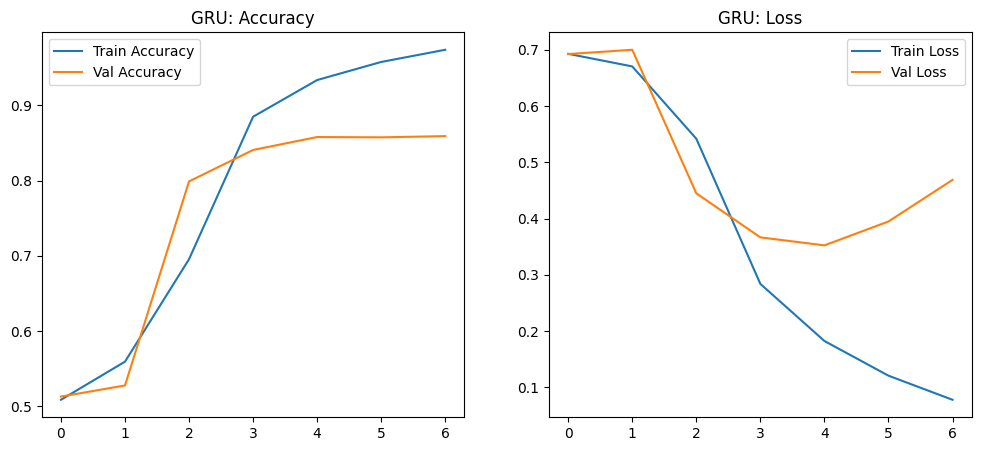

In [13]:
#GRU Training Curve

acc_gru = history_gru.history['accuracy']
val_acc_gru = history_gru.history['val_accuracy']
loss_gru = history_gru.history['accuracy']
val_loss_gru = history_gru.history['val_loss']

epochs = range(1,len(acc)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('GRU: Loss')
plt.legend()
plt.show()

In [ ]:
#Classification Report
y_true_gru = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_gru = gru_model.predict(val_ds)
y_pred_gru = (y_pred_probs > 0.5).astype("int32")

print(classification_report(y_true_gru, y_pred_gru))

#Confusion Matrix

cm_gru = confusion_matrix(y_true_gru, y_pred_gru)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

Next, I performed hyper parameter tuning on the GRU model using keras Tuner.

*   rate = [0.1,0.2,0.3,0.4]
*   units = [32,64,128]
*   dropout = [0.2,0.3,0.5]
*   lr = [1e-3,5e-4,1e-4]

The Tuner will test multiple combinations and the best model will be selected based on the minimum validation loss.Early stoppping is used to restore best weights.



In [15]:
#Hypertuned GRU
#rate = [0.1,0.2,0.3,0.4]
#units = [32,64,128]
#dropout = [0.2,0.3,0.5]
#lr = [1e-3,5e-4,1e-4]

def build_gru_hypermodel(gru):
    model = keras.Sequential()

    #Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=gru.Float('spatial_dropout', min_value=0.1, max_value=0.4, step=0.1)
    ))

    units = gru.Choice("units",[32,64,128])
    dropout = gru.Choice("dropout",[0.2,0.3,0.5])

    model.add(layers.GRU(
        units,
        dropout=dropout,
        recurrent_dropout = dropout
    ))

    #Dense Layer Units
    model.add(layers.Dense(
        units=gru.Int('dense_units', min_value=32, max_value=64, step=32),
        activation='relu'
    ))

    model.add(layers.Dense(1, activation='sigmoid'))


#Learning Rate
    lr = gru.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_gru = kt.RandomSearch(
    build_gru_hypermodel,
    objective='val_loss',
    max_trials=5,
    directory='gru_tuning',
    project_name='imdb_gru_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2,restore_best_weights=True)

tuner_gru.search(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])

# Get the best hyperparameters
best_hps_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
best_hps_gru.values

print(f"Optimal Filters: {best_hps_gru.get('filters')}")
print(f"Optimal Kernel Size: {best_hps_gru.get('kernel_size')}")
print(f"Optimal Spatial Dropout: {best_hps_gru.get('spatial_dropout')}")

# Build the model with the best hyperparameters and train it
best_gru_model = tuner_gru.hypermodel.build(best_hps_gru)
history_gru = best_gru_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[stop_early])

val_loss_history_gru = history_gru.history["val_loss"]
best_epoch_gru = int(np.argmin(val_loss_history_gru))+ 1

gru_tuned_result = {
    "model_name": "GRU_tuned",
    "best_epoch": best_epoch_gru,
    "best_val_loss": float(min(val_loss_history_gru)),
    "best_val_accuracy": float(max(history_gru.history["val_accuracy"])),
    "embedding_dim": best_hps_gru.get("embedding_dim"),
    "units": best_hps_gru.get("units"),
    "dropout": best_hps_gru.get("dropout"),
    "dense_units": best_hps_gru.get("dense_units"),
    "learning_rate": best_hps_gru.get("learning_rate"),
}

print(gru_tuned_result)



Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
0.3               |0.3               |spatial_dropout
32                |32                |units
0.5               |0.5               |dropout
64                |64                |dense_units
0.0005            |0.0005            |learning_rate

Epoch 1/10
 39/625 ━━━━━━━━━━━━━━━━━━━━ 2:43 279ms/step - accuracy: 0.4976 - loss: 0.6934

KeyboardInterrupt: 

In [ ]:
#Loss and Accuracy Plot

acc_gru_tuned = history_gru.history['accuracy']
val_acc_gru_tuned = history_gru.history['val_accuracy']
loss_gru_tuned = history_gru.history['loss']
val_loss_gru_tuned = history_gru.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc_gru_tuned, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc_gru_tuned, 'r-', label='Validation Accuracy')
plt.title('GRU Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss_gru_tuned, 'b-', label='Training Loss')
plt.plot(epochs, val_loss_gru_tuned, 'r-', label='Validation Loss')
plt.title('GRU Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Classification Report
y_true_gru_tuned = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_gru_tuned = gru_model.predict(val_ds)
y_pred_gru_tuned = (y_pred_probs > 0.5).astype("int32")

print(classification_report(y_true_gru_tuned, y_pred_gru_tuned))

#Confusion Matrix

cm_gru_tuned = confusion_matrix(y_true_gru_tuned, y_pred_gru_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru_tuned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

#ROC Curve

fpr_gru_tuned, tpr_gru_tuned, thresholds_gru_tuned = roc_curve(y_true_gru_tuned, y_pred_probs_gru_tuned)
roc_auc_gru_tuned = auc(fpr_gru_tuned, tpr_gru_tuned)

plt.figure(figsize=(6,4))
plt.plot(fpr_gru_tuned, tpr_gru_tuned, label=f"AUC = {roc_auc_gru_tuned:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()